# MULTIPLE LINEAR REGRESSION

## Part A: Develop the model by dividing the given dataset into training and testing sets

This lab focuses on building and evaluating a Multiple Linear Regression model for predicting house prices using multiple independent variables.

## Activity 1 — Store the Data in a CSV File

The house-price dataset is stored in the file `house_price_mlr.csv`.

The dataset contains the following variables:

- `House_ID` — House identifier
- `Area_sqft` — House area in square feet
- `Bedrooms` — Number of bedrooms
- `Bathrooms` — Number of bathrooms
- `Age_years` — Age of the house
- `Distance_km` — Distance from city centre
- `Parking` — Number of parking spaces
- `Locality_Rating` — Locality rating
- `Price_Lakh` — House price in lakh

`Price_Lakh` is the dependent variable, while the remaining variables are predictors.

## Activity 2 — Load and Inspect the Data

The CSV file is loaded using Pandas. The first few rows, dataset shape, data types, and missing values are checked.

In [1]:
import pandas as pd

df = pd.read_csv("house_price_mlr.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
   House_ID  Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_km  Parking  \
0         1        850         2          1         18         12.5        1   
1         2        900         2          2         15         11.8        1   
2         3        950         2          2         12         10.5        1   
3         4       1000         2          2         10          9.8        1   
4         5       1050         3          2          9          9.2        1   

   Locality_Rating  Price_Lakh  
0                5          42  
1                6          47  
2                6          51  
3                7          56  
4                7          61  

Dataset shape:
(18, 9)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   House_ID         18 non-null     int64  
 1   Area_sqft        18 non-nul

### Observations

1. The dataset contains 18 observations and 9 columns.
2. There are 7 predictor variables, 1 dependent variable, and 1 identifier column.
3. `Price_Lakh` is the dependent variable.
4. There are no missing values in the dataset.
5. `Area_sqft`, `Age_years`, `Distance_km`, and `Price_Lakh` are continuous variables.
6. `Bedrooms`, `Bathrooms`, `Parking`, and `Locality_Rating` are discrete/count-type variables.

## Activity 3 — Descriptive Statistics and Exploratory Data Analysis

Descriptive statistics are calculated to understand the centre, spread, minimum, and maximum values of the variables.

A histogram is also plotted to examine the distribution of house prices.

In [2]:
print(df.describe())

        House_ID    Area_sqft   Bedrooms  Bathrooms  Age_years  Distance_km  \
count  18.000000    18.000000  18.000000  18.000000  18.000000    18.000000   
mean    9.500000  1275.000000   2.944444   2.388889   6.388889     7.333333   
std     5.338539   266.926956   0.639137   0.607685   4.840259     2.635727   
min     1.000000   850.000000   2.000000   1.000000   1.000000     3.800000   
25%     5.250000  1062.500000   3.000000   2.000000   3.000000     5.200000   
50%     9.500000  1275.000000   3.000000   2.000000   5.000000     7.000000   
75%    13.750000  1487.500000   3.000000   3.000000   8.750000     9.075000   
max    18.000000  1700.000000   4.000000   3.000000  18.000000    12.500000   

         Parking  Locality_Rating  Price_Lakh  
count  18.000000        18.000000   18.000000  
mean    1.555556         8.000000   82.611111  
std     0.511310         1.414214   26.191914  
min     1.000000         5.000000   42.000000  
25%     1.000000         7.000000   62.000000  


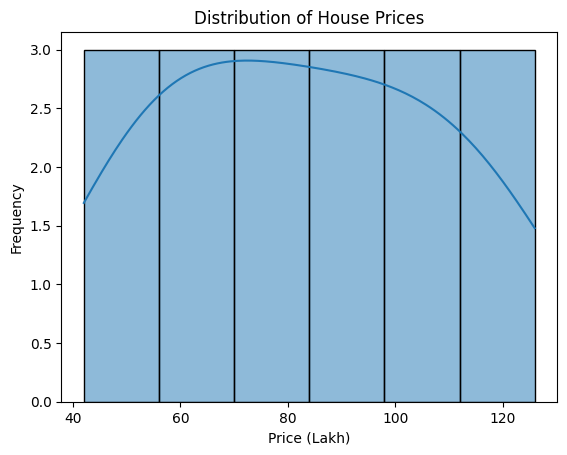

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Price_Lakh"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakh)")
plt.ylabel("Frequency")

plt.show()

### Observation

The house prices range approximately from 42 lakh to 126 lakh. The histogram shows the distribution of house prices across the dataset.

The target variable itself does not need to be normally distributed for Linear Regression. Normality is mainly considered for residuals when classical statistical inference is required.

## Activity 4 — Correlation Analysis

Correlation analysis is performed to examine the relationships between the predictors and house price.

A correlation matrix and heatmap are used for this analysis.

In [4]:
corr = df.drop(columns=["House_ID"]).corr()

print(corr["Price_Lakh"].sort_values(ascending=False))

Price_Lakh         1.000000
Area_sqft          0.999347
Locality_Rating    0.954428
Bathrooms          0.878567
Bedrooms           0.873595
Parking            0.856025
Age_years         -0.932299
Distance_km       -0.979018
Name: Price_Lakh, dtype: float64


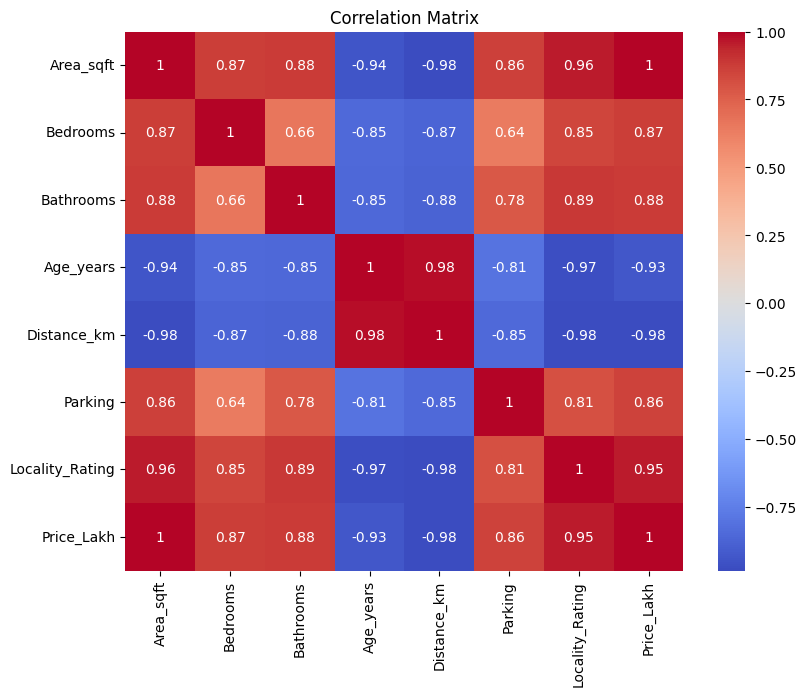

In [5]:
plt.figure(figsize=(9, 7))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

### Questions-Answers

**1. Which predictor has the strongest relationship with price?**

Area_sqft has the strongest positive relationship with Price_Lakh, with a correlation of approximately 1.00. Locality_Rating also has a very strong positive correlation with Price_Lakh (0.95).


**2. Which predictors appear strongly related to one another?**

Several predictors are strongly correlated with each other. For example:

- Area_sqft and Distance_km: -0.98
- Area_sqft and Age_years: -0.94
- Area_sqft and Locality_Rating: 0.96
- Age_years and Distance_km: 0.98
- Age_years and Locality_Rating: -0.97
- Distance_km and Locality_Rating: -0.98

This indicates strong relationships among several predictors.


**3. Why could strong predictor-predictor correlation be a problem?**

Strong correlation between predictors can cause multicollinearity. Multicollinearity can make regression coefficients unstable and difficult to interpret because the model has difficulty separating the individual effect of highly correlated predictors.

## Activity 5 — Define X and y and Split the Data

The predictor variables are stored in `X`, while the dependent variable `Price_Lakh` is stored in `y`.

The dataset is divided into training and testing sets using an 80:20 split.

In [6]:
X = df.drop(columns=["House_ID", "Price_Lakh"])

y = df["Price_Lakh"]

print("Predictor variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Predictor variables:
['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_km', 'Parking', 'Locality_Rating']

Target variable:
Price_Lakh


In [7]:
X = df.drop(columns=["House_ID", "Price_Lakh"])

y = df["Price_Lakh"]

print("Predictor variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Predictor variables:
['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_km', 'Parking', 'Locality_Rating']

Target variable:
Price_Lakh


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 14
Testing observations: 4


### Observation

The dataset is divided into training and testing subsets.

- Training observations: 14
- Testing observations: 4

The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

## Activity 6 — Build the Multiple Linear Regression Model

A Multiple Linear Regression model is created using `LinearRegression()` from scikit-learn.

The general model form is:

ŷ = β₀ + β₁Area + β₂Bedrooms + β₃Bathrooms + β₄Age + β₅Distance + β₆Parking + β₇Locality

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept: -128.66940529132359

Coefficients:
Area_sqft : 0.12790442451194664
Bedrooms : 1.1612120298485145
Bathrooms : 0.6257179467852605
Age_years : -0.41483379814576415
Distance_km : 4.9951006256123645
Parking : 0.31705736036783105
Locality_Rating : 1.141493932313244


### Interpretation of Regression Coefficients

Each regression coefficient represents the expected change in house price for a one-unit increase in that predictor, while keeping all other predictors constant.

The coefficients for at least four predictors are interpreted based on the model output.

## Activity 7 — Predict House Prices

The trained model is used to predict house prices for the testing dataset.

The actual price, predicted price, and residual are compared.

In [10]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": y_test.values - y_pred
})

print(comparison)


   Actual  Predicted  Residual
0      42  43.993774 -1.993774
1      47  49.904138 -2.904138
2      79  79.602819 -0.602819
3      65  65.206754 -0.206754


### Residual

The residual is calculated as:

**Residual = Actual Price − Predicted Price**

A positive residual means that the model underestimated the actual price, while a negative residual means that the model overestimated the actual price.

## Activity 8 — Evaluate the Model

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [11]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.4268711841410493
MSE: 3.203822680343008
RMSE: 1.7899225347324415
R²: 0.9852145477688238


### Interpretation of Evaluation Metrics

**MAE:** Represents the average absolute difference between actual and predicted prices.

**MSE:** Represents the average squared prediction error.

**RMSE:** Represents the typical magnitude of prediction error in the same unit as house price.

**R²:** Represents the proportion of variation in house price explained by the regression model.

## Activity 9 — Calculate Adjusted R²

Adjusted R² is used to account for the number of predictors included in the model.

The formula is:

Adjusted R² = 1 − (1 − R²) × (n − 1) / (n − p − 1)

where:

- n = number of observations
- p = number of predictors

In [12]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 1.0110890891733821


## Activity 10 — Create Residuals

Residuals are calculated as:

**eᵢ = yᵢ − ŷᵢ**

These residuals will be used for the remaining model-assumption diagnostics.

In [13]:
fitted_values = y_pred

residuals = y_test.to_numpy() - y_pred

print("Residual mean:", np.mean(residuals))

Residual mean: -1.4268711841410493


# Part B — Working on Regression Assumptions

The following assumptions/diagnostics are examined:

1. Linearity
2. Independence of errors
3. Homoscedasticity
4. Normality of residuals
5. Multicollinearity
6. Outliers

## Assumption 1 — Linearity

The relationship between the predictors and response should be adequately represented by a linear form.

A Residuals vs Fitted Values plot is used to check for systematic patterns.

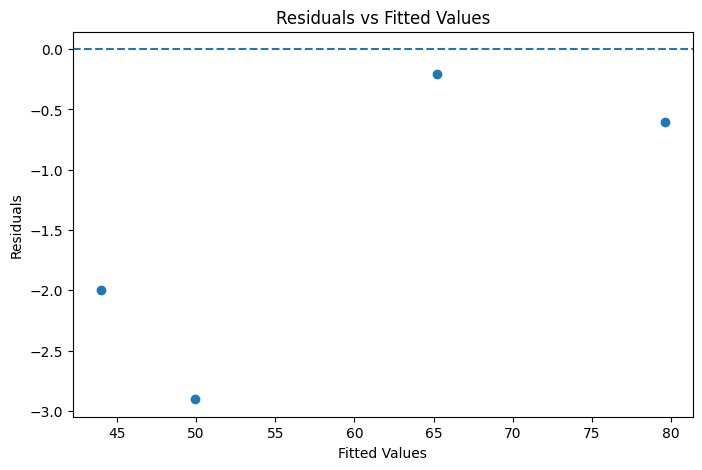

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(fitted_values, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

### Observation

The residuals are examined for systematic curves or patterns.

- Random scatter around zero → linearity is supported.
- Clear curved pattern → possible non-linearity.

The conclusion should be based on the actual residual plot.

## Assumption 2 — Independence of Errors

Independence is assessed using the observation order of residuals and the Durbin-Watson statistic.

For randomly sampled house listings, independence should primarily be justified from the sampling/design context.

In [15]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)

print("Durbin-Watson:", dw)

Durbin-Watson: 0.4901722565991856


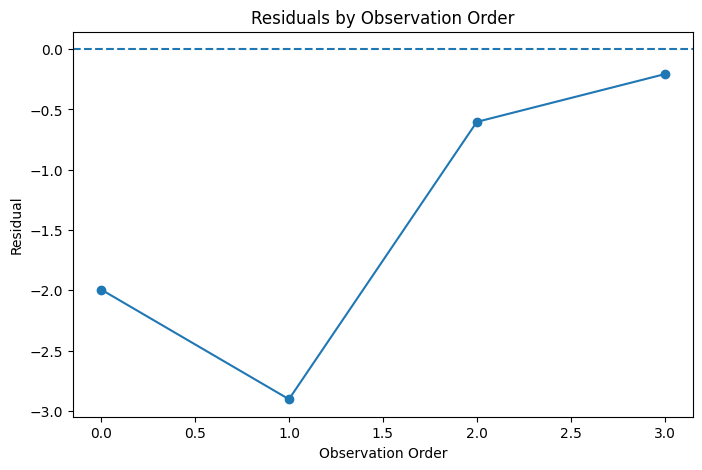

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(len(residuals)),
    residuals,
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Observation Order")
plt.ylabel("Residual")
plt.title("Residuals by Observation Order")

plt.show()

### Interpretation

A Durbin-Watson value near 2 suggests little first-order autocorrelation.

The result should be interpreted together with the observation-order residual plot and the sampling design.

## Assumption 3 — Homoscedasticity

Homoscedasticity means that the residual variance remains approximately constant across fitted values.

A funnel-shaped residual pattern may indicate heteroscedasticity.

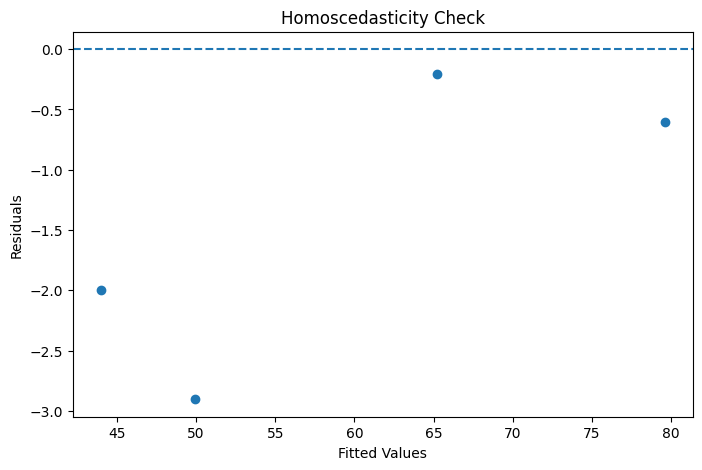

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(fitted_values, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")

plt.show()

### Optional Breusch-Pagan Test

In [18]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(
    residuals,
    np.column_stack([
        np.ones(len(X_test)),
        X_test
    ])
)

print("LM statistic:", bp[0])
print("LM p-value:", bp[1])
print("F statistic:", bp[2])
print("F p-value:", bp[3])

LM statistic: 4.0
LM p-value: 0.779777408475716
F statistic: nan
F p-value: nan


## Assumption 4 — Normality of Residuals

For classical small-sample inference, residuals are often assumed to be approximately normal.

Normality of the raw house-price variable is not required for prediction.

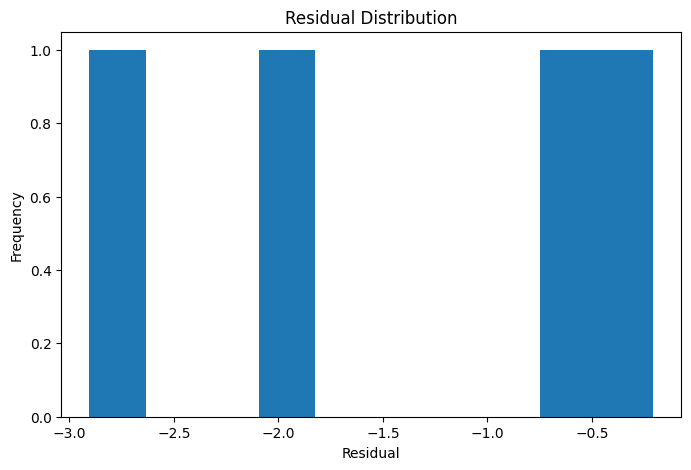

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=10)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

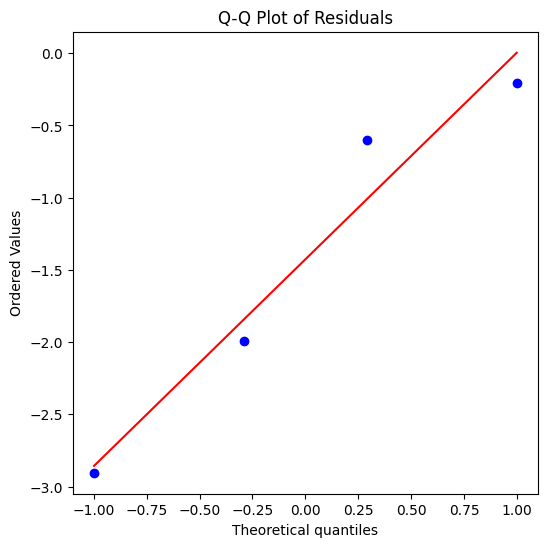

In [20]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")

plt.show()

### Optional Shapiro-Wilk Test

In [21]:
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk statistic: 0.9307582124329731
p-value: 0.5988628313381389


## Assumption 5 — Multicollinearity

Multicollinearity occurs when predictors are strongly related to one another.

Correlation analysis and Variance Inflation Factor (VIF) are used to diagnose multicollinearity.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

           Feature          VIF
0        Area_sqft   894.406488
1         Bedrooms   155.560602
2        Bathrooms   223.363087
3        Age_years   530.923683
4      Distance_km  1349.331686
5          Parking    84.063837
6  Locality_Rating  1410.228596


### VIF Interpretation

- VIF close to 1 → little or no multicollinearity
- VIF between 1 and 5 → often acceptable
- VIF between 5 and 10 → potential concern
- VIF above 10 → serious multicollinearity concern

The actual VIF values should be used to make the final conclusion.

## Assumption 6 — Outliers

Standardized residuals are examined to identify unusual observations.

A large standardized residual should be investigated rather than automatically removed.

In [23]:
standardized_residuals = (
    residuals - np.mean(residuals)
) / np.std(residuals, ddof=1)

print("Standardized residuals:")
print(standardized_residuals)


Standardized residuals:
[-0.45430094 -1.1838426   0.66037359  0.97776995]


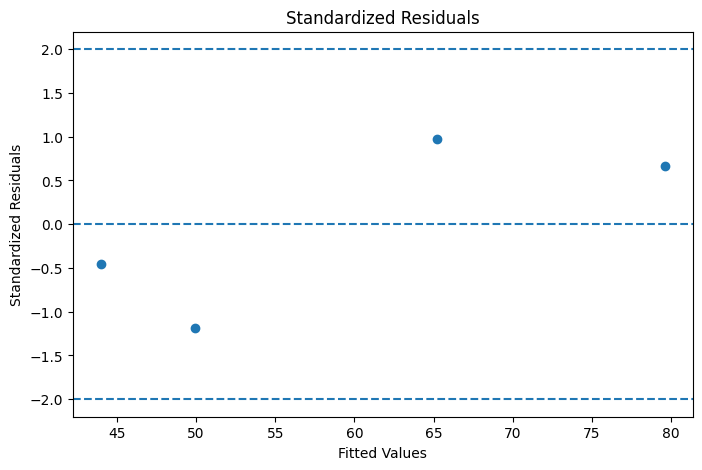

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    standardized_residuals
)

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals")

plt.show()

## Model Improvement Challenge

At least one alternative model is developed and compared with the original model.

The alternative model may remove a highly collinear predictor, add a meaningful transformation, or investigate a suspicious observation.

Observations should not be deleted without a defensible reason.

## Final Assumption Checklist

| Assumption | Diagnostic | Evidence / Result | Conclusion |
|---|---|---|---|
| Linearity | Residual vs Fitted | To be filled | Satisfied / Potential violation |
| Independence | Residual order + DW | To be filled | Satisfied / Potential violation |
| Homoscedasticity | Residual plot + BP | To be filled | Satisfied / Potential violation |
| Normality | Histogram + Q-Q + Shapiro | To be filled | Approximately normal / Potential violation |
| No severe multicollinearity | Correlation + VIF | To be filled | Satisfied / Potential concern |
| No problematic outliers | Standardized residuals | To be filled | No major concern / Investigate |